# 활성화 함수 (Activation Function)

딥러닝의 활성화 함수(Activation Function)란, 뉴런에서 계산된 값에 비선형성(non-linearity)을 부여하여 모델이 복잡한 패턴을 학습할 수 있도록 도와주는 함수이다.

퍼셉트론에서는 계단 함수(step function)를 사용해 입력값을 0 또는 1로 구분하였다.
하지만 딥러닝에서는 층을 여러 개 쌓아 복잡한 패턴을 학습해야 하므로, 더 다양한 활성화 함수가 사용된다.

## 활성화 함수가 왜 필요한가

신경망의 각 층에서는 보통 입력값에 가중치를 곱하고 편향을 더하는 선형 결합을 수행한다.

$ z = Wx + b $

그런데 층을 여러 개 쌓더라도, 중간에서 계속 선형변환만 반복하면 전체 구조도 결국 하나의 큰 선형변환처럼 볼 수 있다.
즉 층이 많아져도 복잡한 비선형 패턴을 충분히 표현하기 어렵다.

따라서 신경망이 더 다양한 패턴을 학습하려면, 중간에 비선형성을 넣어야 한다.
이때 사용하는 함수가 활성화 함수이다.

즉 활성화 함수는 단순히 값을 바꾸는 함수가 아니라,
신경망이 복잡한 문제를 표현할 수 있게 만드는 중요한 장치이다.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

x = np.linspace(-10, 10, 400)

def plot_activation(x, y, title, ylabel='f(x)'):
    plt.figure(figsize=(8, 4))
    plt.axhline(0, color='gray', linestyle='--', linewidth=1)
    plt.axvline(0, color='gray', linestyle='--', linewidth=1)
    plt.plot(x, y, linewidth=2)
    plt.title(title)
    plt.xlabel('x')
    plt.ylabel(ylabel)
    plt.grid(alpha=0.2)
    plt.show()


### 계단 함수 (Step Function)

$ f(x) = \begin{cases} 1, & x \geq 0 \\ 0, & x < 0 \end{cases} $

계단 함수는 퍼셉트론에서 사용한 가장 기본적인 활성화 함수이다.

특징
1. 입력값이 기준 이상이면 1, 아니면 0으로 나눈다.
2. 결과가 매우 직관적이어서 이진 분류 개념을 설명하기 좋다.
3. 값이 갑자기 끊기듯 바뀌기 때문에, 딥러닝의 은닉층에서는 거의 사용하지 않는다.

즉 계단 함수는 퍼셉트론의 출발점을 이해하는 데는 좋지만,
실제 딥러닝 모델의 은닉층에서 널리 쓰이는 함수는 아니다.


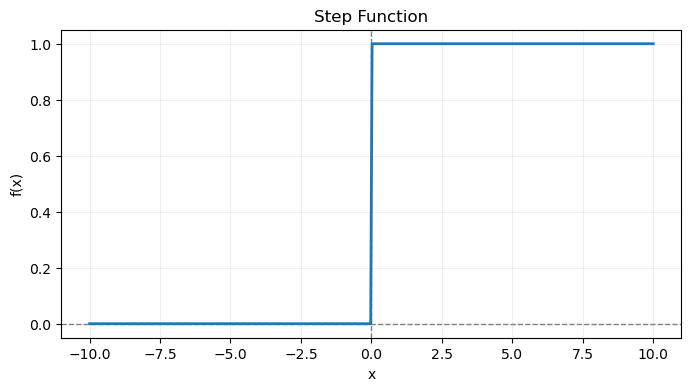

In [2]:
def step_funtion(x):
    return np.where(x >= 0, 1, 0)

y_step = step_funtion(x)
plot_activation(x, y_step, 'Step Function')

### 시그모이드 함수 (Sigmoid Function)

$ f(x) = \frac{1}{1 + e^{-x}} $

시그모이드 함수는 입력값을 0과 1 사이의 값으로 변환한다.

특징
1. 출력값 범위가 0 ~ 1이다.
2. 확률처럼 해석하기 쉬운 형태를 만든다.
3. 이진 분류 출력층과 자주 연결된다.
4. 입력이 매우 크거나 매우 작아지면 기울기가 작아질 수 있다.

즉 시그모이드는 “확률처럼 보이는 출력”을 만들기 좋지만,
깊은 은닉층에서 반복적으로 사용하는 데에는 한계가 있을 수 있다.


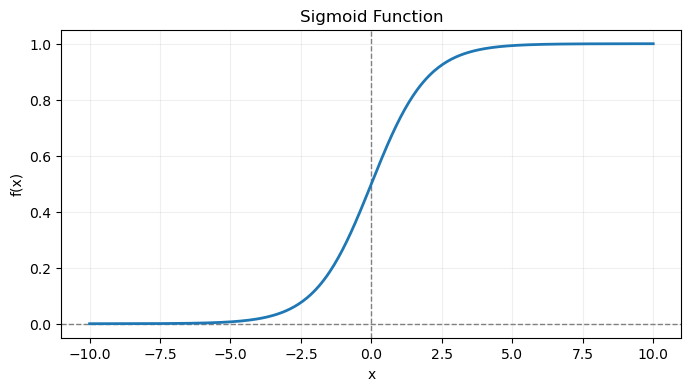

In [3]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

y_sigmoid = sigmoid(x)
plot_activation(x, y_sigmoid, 'Sigmoid Function')

### 하이퍼볼릭 탄젠트 함수 (Hyperbolic Tangent, Tanh)

$ f(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}} $

tanh 함수는 출력값이 -1과 1 사이에 위치한다.

특징
1. 출력 범위가 -1 ~ 1이다.
2. 0을 중심으로 대칭적인 형태를 가진다.
3. 시그모이드보다 중심이 0에 가까워 학습에 유리할 때가 있다.
4. 하지만 깊은 층에서는 여전히 기울기 소실 문제가 나타날 수 있다.

즉 tanh는 sigmoid보다 중심 정렬 측면에서 장점이 있지만,
깊은 네트워크에서 항상 최선의 선택은 아닐 수 있다.


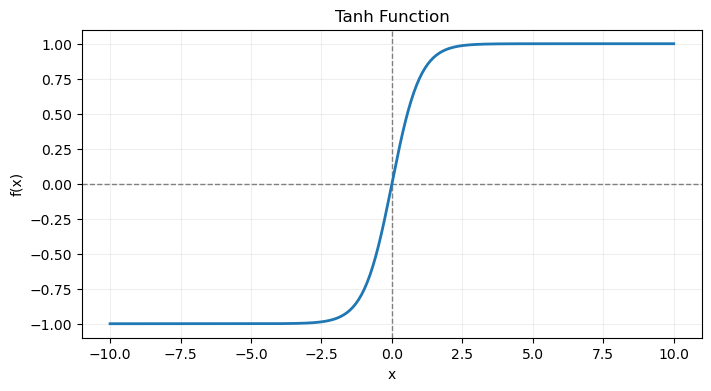

In [5]:
def tanh(x):
    return np.tanh(x)

y_tanh = tanh(x)
plot_activation(x, y_tanh, 'Tanh Function')

### ReLU (Rectified Linear Unit)

$ f(x) = \max(0, x) $

ReLU는 입력이 0보다 크면 그대로 두고, 0보다 작으면 0으로 만든다.

특징
1. 음수는 0, 양수는 그대로 유지한다.
2. 구조가 단순하고 계산이 빠르다.
3. 은닉층에서 매우 자주 사용된다.
4. sigmoid, tanh에 비해 깊은 신경망에서 유리한 경우가 많다.
5. 음수 구간이 전부 0이기 때문에, 일부 뉴런이 계속 0만 출력하는 문제가 생길 수도 있다.

즉 ReLU는 딥러닝 은닉층에서 대표적으로 많이 쓰이는 활성화 함수이다.


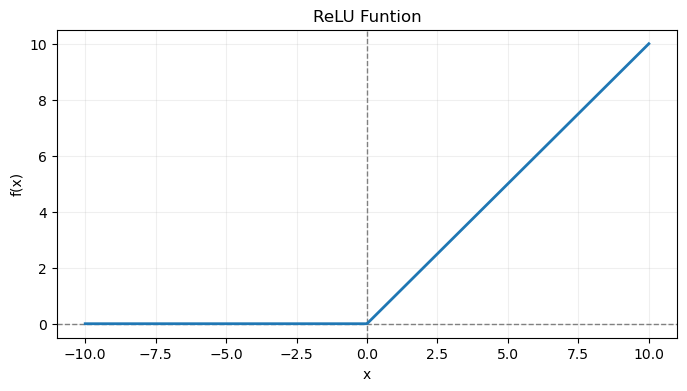

In [6]:
def relu(x):
    return np.maximum(0, x)

y_relu = relu(x)
plot_activation(x, y_relu, 'ReLU Funtion')

### Leaky ReLU

$ f(x) = \begin{cases} x, & x \geq 0 \\ \alpha x, & x < 0 \end{cases} $

Leaky ReLU는 ReLU를 조금 보완한 형태이다.

특징
1. 양수 구간에서는 ReLU와 동일하게 동작한다.
2. 음수 구간에서도 완전히 0으로 만들지 않고, 작은 기울기를 남긴다.
3. ReLU의 죽은 뉴런 문제를 완화하는 데 도움을 줄 수 있다.

즉 Leaky ReLU는 ReLU의 장점을 유지하면서,
음수 구간을 완전히 막지 않도록 조정한 함수라고 볼 수 있다.


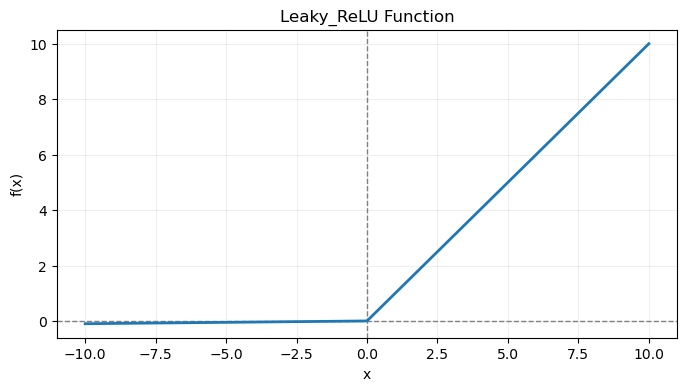

In [7]:
def leaky_relu(x, alpha=0.01):
    return np.where(x >= 0, x, alpha * x)

y_leaky_relu = leaky_relu(x)
plot_activation(x, y_leaky_relu, 'Leaky_ReLU Function')

## Softmax

softmax 함수는 여러 출력값을 확률처럼 보이게 만들어주는 함수이다.

$ softmax(x_i) = \frac{e^{x_i}}{\sum_j e^{x_j}} $

특징
1. 여러 클래스 점수를 0과 1 사이 값으로 바꾼다.
2. 각 값의 합이 1이 되므로 확률 분포처럼 해석할 수 있다.
3. 다중분류 출력층에서 자주 사용된다.

즉 softmax는 은닉층에서 주로 사용하는 함수라기보다,
여러 클래스 중 하나를 고르는 다중분류 출력과 더 강하게 연결된다.


In [8]:
def softmax(x):
    x = np.array(x)
    exp_x = np.exp(x - np.max(x))   # 최대값 빼서 오버플로우 방지
    return exp_x / np.sum(exp_x)

scores = np.array([2.0, 1.0, 0.1])
softmax_scores = softmax(scores)

result_df = pd.DataFrame({
    'class_score' : scores,
    'softmax_probabilty' : softmax_scores
}, index=['class_0', 'class_1', 'class_2'])

result_df

,class_score,softmax_probabilty
class_0,2.0,0.659001
class_1,1.0,0.242433
class_2,0.1,0.098566


## 활성화 함수 비교 정리

| 함수 | 출력 범위 | 주된 역할/특징 | 주로 연결되는 위치 |
|---|---|---|---|
| Step | 0 또는 1 | 퍼셉트론 개념 설명에 적합 | 퍼셉트론 기초 설명 |
| Sigmoid | 0 ~ 1 | 확률처럼 해석하기 쉬움 | 이진분류 출력층 |
| Tanh | -1 ~ 1 | 0 중심 대칭 | 은닉층에서 사용 가능 |
| ReLU | 0 이상 | 단순하고 많이 사용됨 | 은닉층 |
| Leaky ReLU | 음수 구간 작은 기울기 허용 | ReLU 보완 | 은닉층 |
| Softmax | 합이 1인 확률 분포 | 여러 클래스 확률화 | 다중분류 출력층 |


1. 퍼셉트론의 출발점은 step function이다.
2. 이진분류 출력층에서는 sigmoid를 자주 보게 된다.
3. 은닉층에서는 ReLU 계열이 많이 사용된다.
4. 다중분류 출력층에서는 softmax가 자주 연결된다.

In [10]:
import torch
import torch.nn as nn

# 예시 입력 텐서
x = torch.tensor([-2.0, -0.5, 0.0, 0.5, 2.0])

# 활성화 함수 객체 생성
sigmoid_fn = nn.Sigmoid()
tanh_fn = nn.Tanh()
relu_fn = nn.ReLU()
leaky_relu_fn = nn.LeakyReLU(negative_slope=0.01)

print('입력 값 x')
print(x)

print('Sigmoid 적용 값')
print(sigmoid_fn(x))

print('Tanh 적용 값')
print(tanh_fn(x))

print('ReLU 적용 값')
print(relu_fn(x))

print('LeakyReLU 적용 값')
print(leaky_relu_fn(x))

# softmax는 여러 값의 상대적 크기를 확률처럼 바꿀 때 자주 사용한다.
scores = torch.tensor([2.0, 1.0, 0.1])

print('Softmax 적용 전 점수')
print(scores)

print('Softmax 적용 결과')
print(torch.softmax(scores, dim=0))

입력 값 x
tensor([-2.0000, -0.5000,  0.0000,  0.5000,  2.0000])
Sigmoid 적용 값
tensor([0.1192, 0.3775, 0.5000, 0.6225, 0.8808])
Tanh 적용 값
tensor([-0.9640, -0.4621,  0.0000,  0.4621,  0.9640])
ReLU 적용 값
tensor([0.0000, 0.0000, 0.0000, 0.5000, 2.0000])
LeakyReLU 적용 값
tensor([-0.0200, -0.0050,  0.0000,  0.5000,  2.0000])
Softmax 적용 전 점수
tensor([2.0000, 1.0000, 0.1000])
Softmax 적용 결과
tensor([0.6590, 0.2424, 0.0986])
